# Bank Marketing Campaign Analysis

## Project Objective
This project analyzes a bank's direct marketing campaign to identify the customer characteristics and campaign factors associated with term-deposit subscriptions.

## Business Questions
- What is the overall campaign conversion rate?
- Which customer segments have the highest subscription rates?
- How do age, occupation, education, and account balance relate to subscription behaviour?
- What recommendations can help the bank improve campaign targeting?

## Dataset
 The dataset contains 45,211 customer records and 17 variables covering customer demographics, financial information, campaign interactions, and subscription outcomes.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#Display all columns
pd.set_option("display.max_columns", None)

#Improve plot appearance
plt.style.use("ggplot")

## Load the Dataset

In [2]:
df = pd.read_csv("bank-full.csv", sep = ";")

In [30]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 45,211
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data Quality Assessment

In [4]:
print("Row and Columns:", df.shape)
df.info()

Row and Columns: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [33]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [10]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [11]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [12]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## Exploratory Data Analysis (EDA)

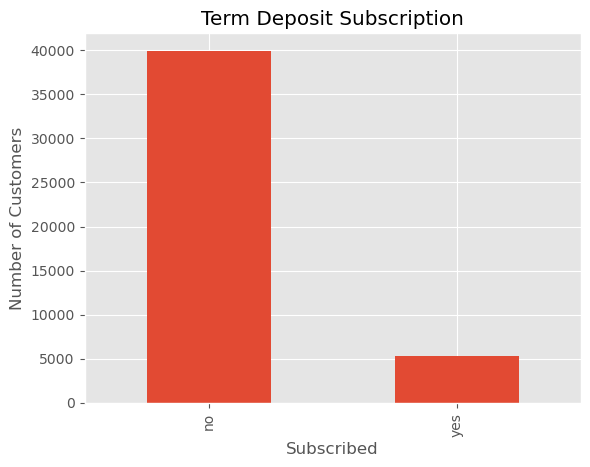

In [16]:
df["y"].value_counts().plot(kind="bar")

plt.title("Term Deposit Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")
plt.show()

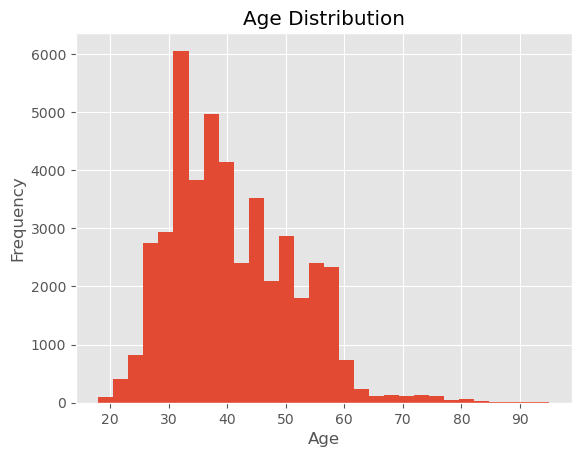

In [17]:
df["age"].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

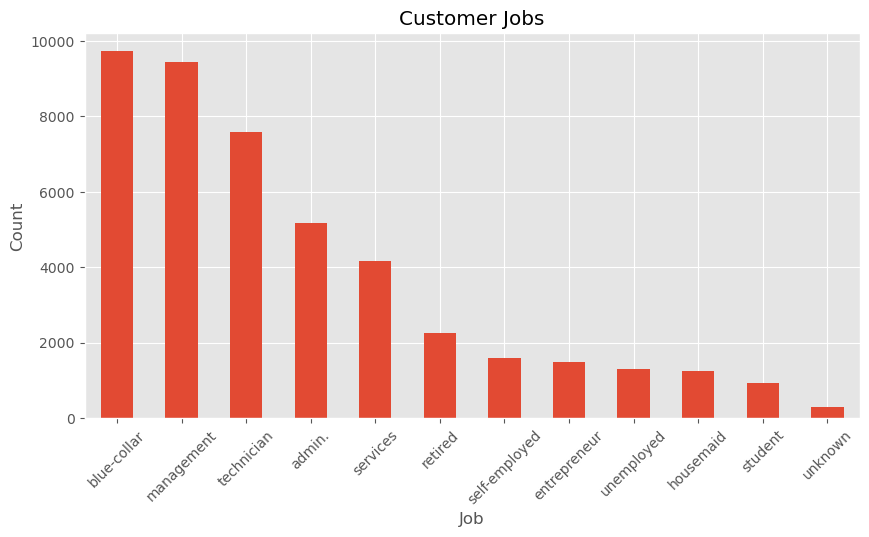

In [18]:
df["job"].value_counts().plot(kind="bar", figsize=(10, 5))

plt.title("Customer Jobs")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

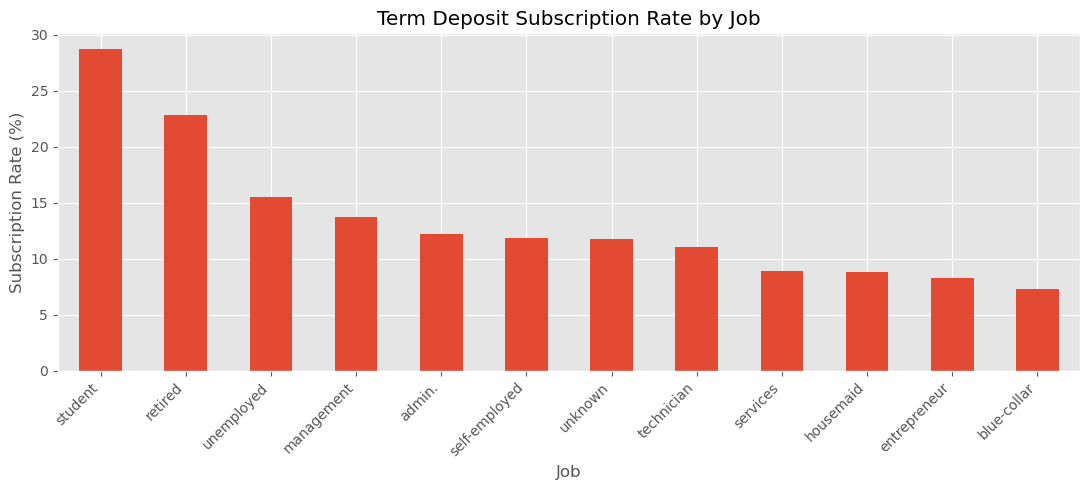

In [32]:
job_subscription_rate = (
    pd.crosstab(df["job"], df["y"], normalize="index")["yes"]
    .mul(100)
    .sort_values(ascending=False)
)

job_subscription_rate.plot(kind="bar", figsize=(11, 5))

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation
Students and retired customers show the strongest subscription rates, while blue-collar and entrepreneur segments have comparatively lower conversion.
### Business Implication 
The bank could test more targeted campaigns for high-performing groups while developing different messaging or offers for lower-performing customer segments.

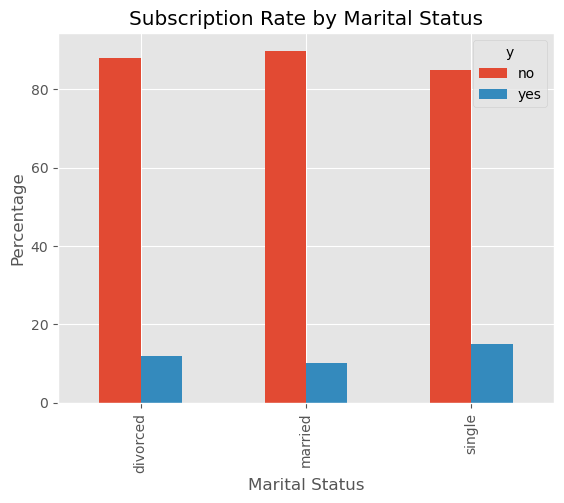

In [21]:
marital_sub = pd.crosstab(df["marital"], df["y"], normalize="index") * 100
marital_sub.plot(kind="bar")

plt.title("Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage")
plt.show()

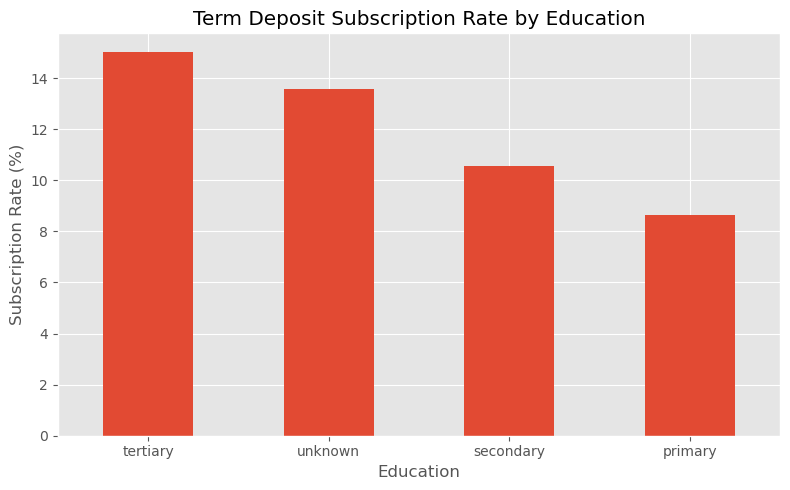

In [31]:
education_subscription_rate = (
    pd.crosstab(df["education"], df["y"], normalize="index")["yes"]
    .mul(100)
    .sort_values(ascending=False)
)

education_subscription_rate.plot(kind="bar", figsize=(8, 5))

plt.title("Term Deposit Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
df.groupby("y")["balance"].mean()

y
no     1303.714969
yes    1804.267915
Name: balance, dtype: float64

# Final Conclusions

The bank's term-deposit campaign achieved an overall subscription rate of approximately 11.7%. Customer response varied meaningfully across occupation, education, age, financial profile, and campaign history.

## Key Findings
- Students and retired customers had the strongest subscription rates by occupation.
- Customers with tertiary education converted at a higher rate than primary-education customers.
- The target variable is imbalanced, with substantially fewer subscribers than non-subscribers.
- Customer and campaign characteristics can support more focused marketing decisions.

## Recommendations
- Prioritize high-converting customer segments for future outreach.
- Develop customized campaign messages for lower-performing groups.
- Use previous campaign outcomes and customer financial characteristics to improve targeting.
- Avoid using call duration for pre-campaign targeting because it is only known after the call has occurred.

## Limitations
- The analysis identifies associations, not causation.
- Several categorical fields contain unknown values.
- The dataset does not include a year field for the campaign month.